In [4]:
# Crime Hotspot Detection Project
# Using LAPD Crime Data (2020-2024)

# =============================================================================
# PART 1: IMPORT LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 60)
print("CRIME HOTSPOT DETECTION - LAPD DATA (2020-2024)")
print("=" * 60)
print("\n✓ Libraries imported successfully!\n")

CRIME HOTSPOT DETECTION - LAPD DATA (2020-2024)

✓ Libraries imported successfully!



In [5]:
# =============================================================================
# PART 2: LOAD DATA
# =============================================================================

# Load the dataset
file_path = 'LA_Crime_Data_from_2020_to_2024.csv'  # Update path as needed
print(f"Loading dataset from: {file_path}")

df = pd.read_csv(file_path)

print(f"✓ Dataset loaded successfully!")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
print(df.head())

Loading dataset from: LA_Crime_Data_from_2020_to_2024.csv
✓ Dataset loaded successfully!
  Shape: 901357 rows × 28 columns

First few rows:
       DR_NO               Date Rptd                DATE OCC  TIME OCC  AREA  \
0  190326475  03/01/2020 12:00:00 AM  03/01/2020 12:00:00 AM      2130     7   
1  200106753  02/09/2020 12:00:00 AM  02/08/2020 12:00:00 AM      1800     1   
2  200320258  11/11/2020 12:00:00 AM  11/04/2020 12:00:00 AM      1700     3   
3  200907217  05/10/2023 12:00:00 AM  03/10/2020 12:00:00 AM      2037     9   
4  220614831  08/18/2022 12:00:00 AM  08/17/2020 12:00:00 AM      1200     6   

   AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
0   Wilshire          784         1     510   
1    Central          182         1     330   
2  Southwest          356         1     480   
3   Van Nuys          964         1     343   
4  Hollywood          666         2     354   

                                Crm Cd Desc  ... Status   Status Desc  \
0                      

In [6]:
# =============================================================================
# PART 3: DATA EXPLORATION
# =============================================================================

print("\n" + "=" * 60)
print("DATA EXPLORATION")
print("=" * 60)

print("\nColumn Names and Data Types:")
print(df.dtypes)

print("\n" + "-" * 60)
print("MISSING VALUES ANALYSIS")
print("-" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])

print("\n" + "-" * 60)
print("BASIC STATISTICS")
print("-" * 60)
print(df.describe())


DATA EXPLORATION

Column Names and Data Types:
DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object

------------------------------------------------------------
MISSING VALUES ANALYSIS
------------------------------------------------------------
                Missing_Count  Percentage
Crm Cd 4             

In [7]:
# =============================================================================
# PART 4: DATA PREPROCESSING
# =============================================================================

print("\n" + "=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# Create a clean copy
df_clean = df.copy()

# Identify latitude and longitude columns
if 'LAT' in df.columns and 'LON' in df.columns:
    lat_col, lon_col = 'LAT', 'LON'
elif 'Latitude' in df.columns and 'Longitude' in df.columns:
    lat_col, lon_col = 'Latitude', 'Longitude'
else:
    # Find lat/lon columns dynamically
    lat_col = [c for c in df.columns if 'lat' in c.lower()][0]
    lon_col = [c for c in df.columns if 'lon' in c.lower()][0]

print(f"\n✓ Using coordinate columns: {lat_col}, {lon_col}")

# Remove rows with missing or invalid coordinates
initial_count = len(df_clean)
df_clean = df_clean.dropna(subset=[lat_col, lon_col])
df_clean = df_clean[(df_clean[lat_col] != 0) & (df_clean[lon_col] != 0)]
df_clean = df_clean[(df_clean[lat_col].between(33, 35)) & (df_clean[lon_col].between(-119, -117))]

print(f"✓ Cleaned dataset shape: {df_clean.shape}")
print(f"✓ Removed {initial_count - len(df_clean):,} rows with invalid coordinates")

# Create coordinate array for clustering
coordinates = df_clean[[lat_col, lon_col]].values
print(f"✓ Coordinates array shape: {coordinates.shape}")

# Sample data if too large (for faster processing)
MAX_SAMPLES = 50000
if len(coordinates) > MAX_SAMPLES:
    print(f"\n⚠ Sampling {MAX_SAMPLES:,} points for faster processing...")
    sample_indices = np.random.choice(len(coordinates), MAX_SAMPLES, replace=False)
    coordinates_sample = coordinates[sample_indices]
    df_sample = df_clean.iloc[sample_indices]
else:
    coordinates_sample = coordinates
    df_sample = df_clean

print(f"✓ Working with {len(coordinates_sample):,} data points")


DATA PREPROCESSING

✓ Using coordinate columns: LAT, LON
✓ Cleaned dataset shape: (899094, 28)
✓ Removed 2,263 rows with invalid coordinates
✓ Coordinates array shape: (899094, 2)

⚠ Sampling 50,000 points for faster processing...
✓ Working with 50,000 data points



CREATING EXPLORATORY VISUALIZATIONS
✓ Saved: 01_crime_distribution.png


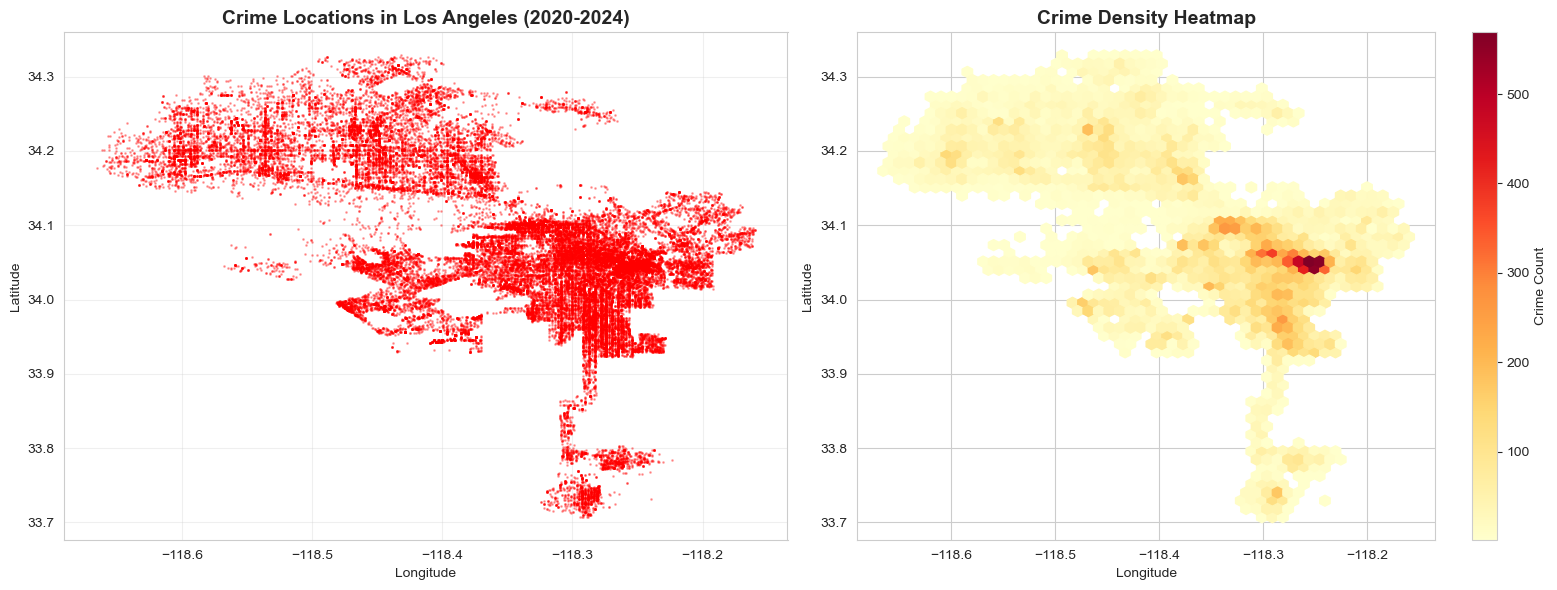

In [8]:
# =============================================================================
# PART 5: EXPLORATORY VISUALIZATIONS
# =============================================================================

print("\n" + "=" * 60)
print("CREATING EXPLORATORY VISUALIZATIONS")
print("=" * 60)

# Visualization 1: Crime Distribution by Location
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(coordinates_sample[:, 1], coordinates_sample[:, 0], 
                alpha=0.3, s=1, c='red')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Crime Locations in Los Angeles (2020-2024)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Density plot
axes[1].hexbin(coordinates_sample[:, 1], coordinates_sample[:, 0], 
               gridsize=50, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Crime Density Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Crime Count')

plt.tight_layout()
plt.savefig('01_crime_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 01_crime_distribution.png")
plt.show()


K-MEANS CLUSTERING FOR HOTSPOT DETECTION

Finding optimal number of clusters...


  File "c:\Users\jangr\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\jangr\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jangr\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jangr\anaconda3\Lib\subprocess.

  K=3: Inertia=30614.22, Silhouette=0.537
  K=4: Inertia=21718.81, Silhouette=0.443
  K=5: Inertia=15605.24, Silhouette=0.464
  K=6: Inertia=11954.00, Silhouette=0.434
  K=7: Inertia=9384.02, Silhouette=0.453
  K=8: Inertia=8057.63, Silhouette=0.439
  K=9: Inertia=7326.04, Silhouette=0.416
  K=10: Inertia=6738.74, Silhouette=0.414

✓ Saved: 02_kmeans_optimization.png


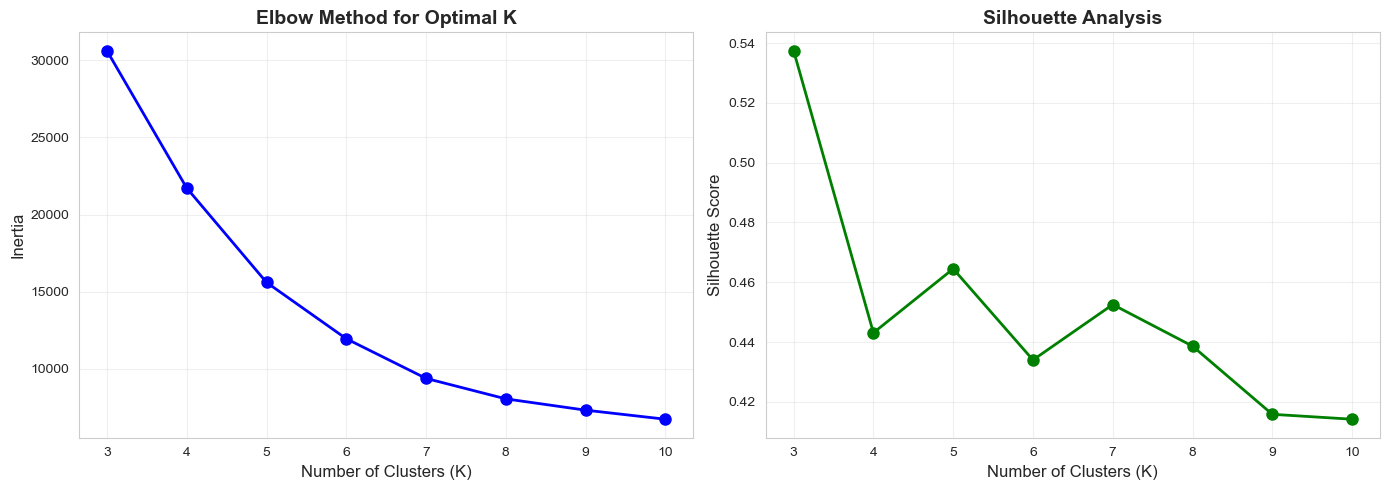


✓ Applying K-Means with K=6 clusters...

K-Means Performance Metrics:
  Silhouette Score: 0.4340
  Davies-Bouldin Index: 0.7153
✓ Saved: 03_kmeans_clusters.png


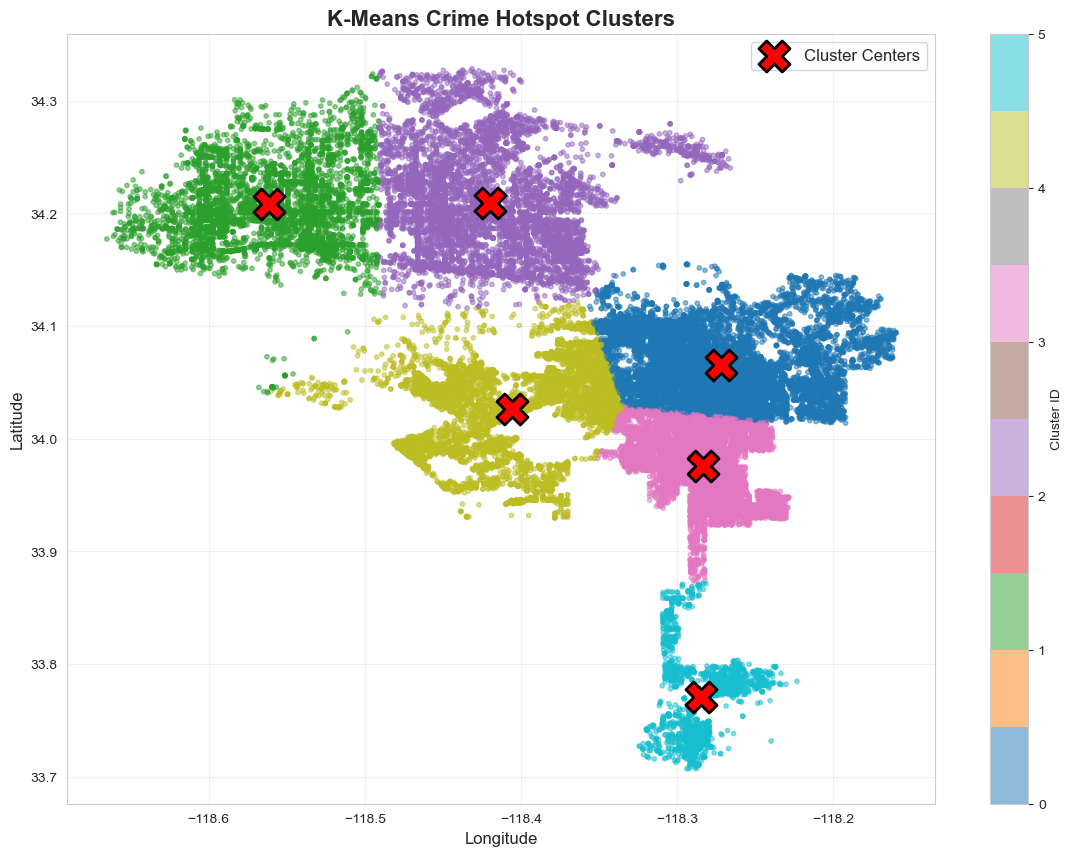

In [9]:
# =============================================================================
# PART 6: K-MEANS CLUSTERING
# =============================================================================

print("\n" + "=" * 60)
print("K-MEANS CLUSTERING FOR HOTSPOT DETECTION")
print("=" * 60)

# Standardize coordinates
scaler = StandardScaler()
coordinates_scaled = scaler.fit_transform(coordinates_sample)

# Find optimal number of clusters using Elbow Method
inertias = []
silhouette_scores = []
K_range = range(3, 11)

print("\nFinding optimal number of clusters...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coordinates_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(coordinates_scaled, kmeans.labels_))
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}")

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_kmeans_optimization.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 02_kmeans_optimization.png")
plt.show()

# Apply K-Means with optimal K
optimal_k = 6  # Choose based on elbow curve
print(f"\n✓ Applying K-Means with K={optimal_k} clusters...")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_sample['KMeans_Cluster'] = kmeans_final.fit_predict(coordinates_scaled)

# Get cluster centers in original scale
cluster_centers = scaler.inverse_transform(kmeans_final.cluster_centers_)

# Evaluate
silhouette_kmeans = silhouette_score(coordinates_scaled, df_sample['KMeans_Cluster'])
davies_bouldin_kmeans = davies_bouldin_score(coordinates_scaled, df_sample['KMeans_Cluster'])

print(f"\nK-Means Performance Metrics:")
print(f"  Silhouette Score: {silhouette_kmeans:.4f}")
print(f"  Davies-Bouldin Index: {davies_bouldin_kmeans:.4f}")

# Visualize K-Means clusters
plt.figure(figsize=(14, 10))
scatter = plt.scatter(df_sample[lon_col], df_sample[lat_col], 
                     c=df_sample['KMeans_Cluster'], cmap='tab10', 
                     alpha=0.5, s=10)
plt.scatter(cluster_centers[:, 1], cluster_centers[:, 0], 
           c='red', marker='X', s=500, edgecolors='black', linewidths=2,
           label='Cluster Centers')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('K-Means Crime Hotspot Clusters', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('03_kmeans_clusters.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 03_kmeans_clusters.png")
plt.show()


DBSCAN CLUSTERING FOR HOTSPOT DETECTION

✓ Applying DBSCAN (eps=0.1, min_samples=50)...

DBSCAN Results:
  Number of clusters: 5
  Number of noise points: 603 (1.2%)

DBSCAN Performance Metrics (excluding noise):
  Silhouette Score: 0.0628
  Davies-Bouldin Index: 0.6169
✓ Saved: 04_dbscan_clusters.png


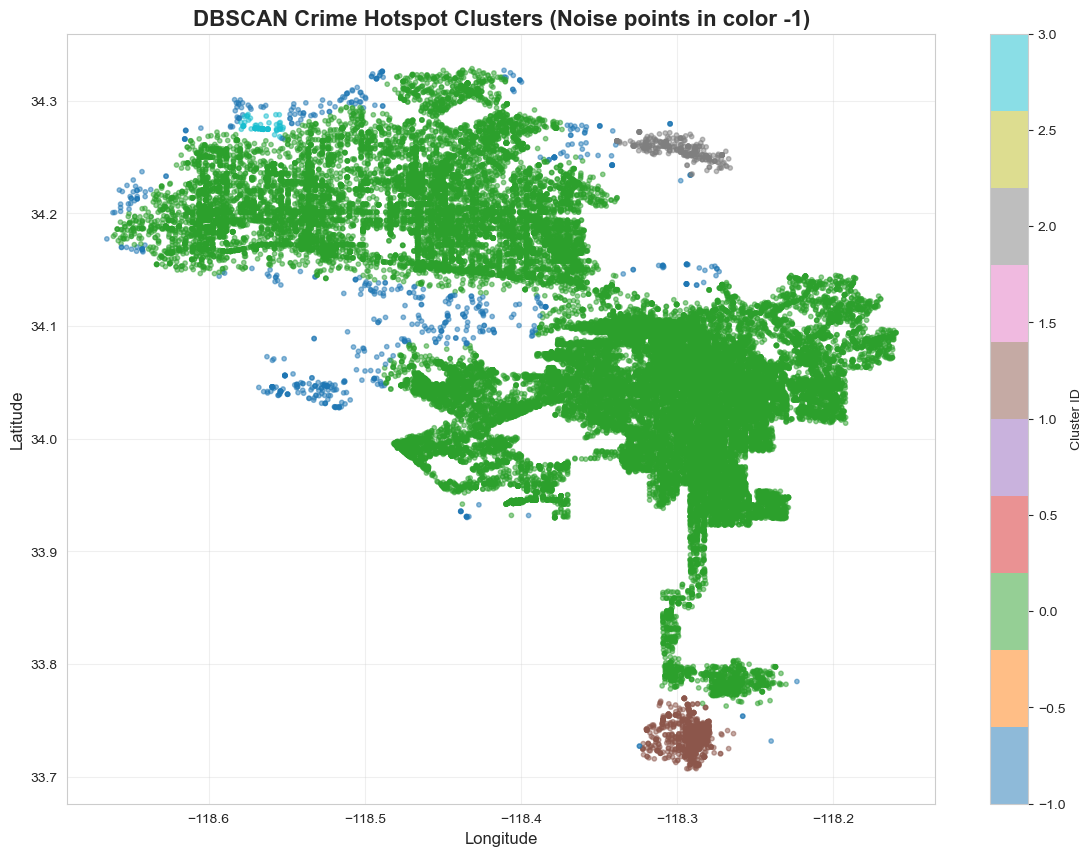

In [10]:
# =============================================================================
# PART 7: DBSCAN CLUSTERING
# =============================================================================

print("\n" + "=" * 60)
print("DBSCAN CLUSTERING FOR HOTSPOT DETECTION")
print("=" * 60)

# Apply DBSCAN
eps = 0.1  # Adjust based on data scale
min_samples = 50

print(f"\n✓ Applying DBSCAN (eps={eps}, min_samples={min_samples})...")
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
df_sample['DBSCAN_Cluster'] = dbscan.fit_predict(coordinates_scaled)

# Count clusters and noise points
n_clusters_dbscan = len(set(df_sample['DBSCAN_Cluster'])) - (1 if -1 in df_sample['DBSCAN_Cluster'] else 0)
n_noise = list(df_sample['DBSCAN_Cluster']).count(-1)

print(f"\nDBSCAN Results:")
print(f"  Number of clusters: {n_clusters_dbscan}")
print(f"  Number of noise points: {n_noise:,} ({n_noise/len(df_sample)*100:.1f}%)")

# Evaluate DBSCAN (excluding noise)
if n_clusters_dbscan > 1:
    mask = df_sample['DBSCAN_Cluster'] != -1
    if mask.sum() > 0:
        silhouette_dbscan = silhouette_score(coordinates_scaled[mask], 
                                            df_sample.loc[mask, 'DBSCAN_Cluster'])
        davies_bouldin_dbscan = davies_bouldin_score(coordinates_scaled[mask], 
                                                     df_sample.loc[mask, 'DBSCAN_Cluster'])
        print(f"\nDBSCAN Performance Metrics (excluding noise):")
        print(f"  Silhouette Score: {silhouette_dbscan:.4f}")
        print(f"  Davies-Bouldin Index: {davies_bouldin_dbscan:.4f}")

# Visualize DBSCAN clusters
plt.figure(figsize=(14, 10))
scatter = plt.scatter(df_sample[lon_col], df_sample[lat_col], 
                     c=df_sample['DBSCAN_Cluster'], cmap='tab10', 
                     alpha=0.5, s=10)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('DBSCAN Crime Hotspot Clusters (Noise points in color -1)', 
          fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.savefig('04_dbscan_clusters.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 04_dbscan_clusters.png")
plt.show()


HOTSPOT ANALYSIS

Crime Hotspot Analysis (K-Means):
                Avg_Latitude  Crime_Count  Avg_Longitude Hotspot_Severity
KMeans_Cluster                                                           
0                    34.0654        17018      -118.2722             High
2                    34.2092         8950      -118.4198           Medium
3                    33.9755         8583      -118.2838           Medium
4                    34.0267         7764      -118.4055           Medium
1                    34.2080         5616      -118.5612              Low
5                    33.7710         2069      -118.2851              Low

✓ Saved: 05_cluster_analysis.png


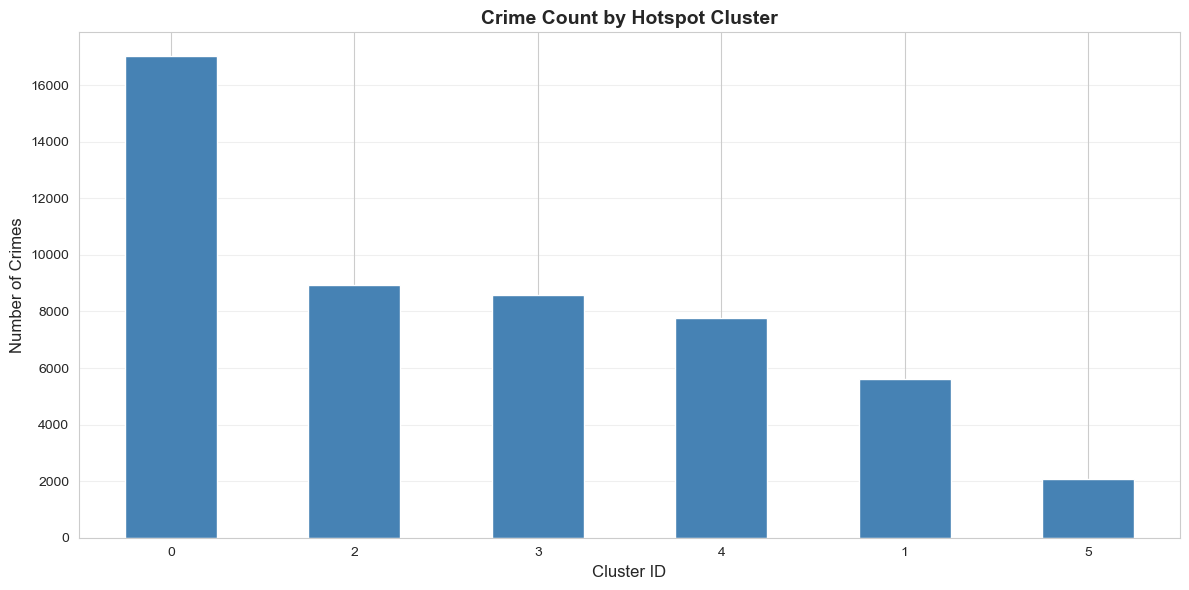

In [11]:
# =============================================================================
# PART 8: HOTSPOT ANALYSIS
# =============================================================================

print("\n" + "=" * 60)
print("HOTSPOT ANALYSIS")
print("=" * 60)

# Analyze K-Means clusters
cluster_analysis = df_sample.groupby('KMeans_Cluster').agg({
    lat_col: ['mean', 'count'],
    lon_col: 'mean'
}).round(4)

cluster_analysis.columns = ['Avg_Latitude', 'Crime_Count', 'Avg_Longitude']
cluster_analysis = cluster_analysis.sort_values('Crime_Count', ascending=False)
cluster_analysis['Hotspot_Severity'] = pd.cut(cluster_analysis['Crime_Count'], 
                                               bins=3, labels=['Low', 'Medium', 'High'])

print("\nCrime Hotspot Analysis (K-Means):")
print(cluster_analysis)

# Visualize cluster sizes
fig, ax = plt.subplots(figsize=(12, 6))
cluster_analysis['Crime_Count'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Number of Crimes', fontsize=12)
ax.set_title('Crime Count by Hotspot Cluster', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('05_cluster_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 05_cluster_analysis.png")
plt.show()